In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
import math

from tqdm import tqdm

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

In [2]:
def entropy(x, b):
    s = 0
    for p in x:
        if p > 0:
            s += -p * math.log(p, b)
    return s

def visualize_regions_keras(model, MAX, nGrid):
    a1 = np.linspace(-MAX, MAX, nGrid)
    a2 = np.linspace(-MAX, MAX, nGrid)
    A1, A2 = np.meshgrid(a1, a2)
    A1 = A1.flatten()
    A2 = A2.flatten()
    A = np.vstack((A1, A2)).T
    B = model.predict(A, verbose=0).argmax(axis=1)
    B = B.reshape(nGrid, nGrid)
    B = np.flipud(B)
    prob_2D = model.predict(A, verbose=0)
    S = np.array([entropy(p, 2) for p in prob_2D])
    S = S.reshape(nGrid, nGrid)
    S = np.flipud(S)
    return B, S

import networkx as nx
from keras.layers import Dense

def _get_model_graph_data(model):
    layer_sizes = []
    layer_weights = []
    layer_labels = []
    current_utility_ops = []

    for layer in model.layers:
        layer_type = layer.__class__.__name__
        if layer_type == 'Dense':
            weights_data = layer.get_weights()
            if not weights_data:
                continue
            W = weights_data[0]
            if len(layer_sizes) == 0:
                layer_sizes.append(W.shape[0])
                layer_labels.append("Input")
            layer_sizes.append(W.shape[1])
            layer_weights.append(W.copy())
            act_name = layer.activation.__name__ if hasattr(layer, 'activation') else 'linear'
            label = f"Dense\n({act_name})"
            if current_utility_ops:
                label = "+ " + "\n+ ".join(current_utility_ops) + "\n" + label
                current_utility_ops = []
            layer_labels.append(label)
        elif layer_type in ['Dropout', 'BatchNormalization', 'Activation']:
            if layer_type == 'Dropout':
                current_utility_ops.append(f"Drop({layer.rate})")
            elif layer_type == 'BatchNormalization':
                current_utility_ops.append("BatchNorm")
            elif layer_type == 'Activation':
                act_name = layer.activation.__name__ if hasattr(layer, 'activation') else 'act'
                current_utility_ops.append(f"Act({act_name})")

    return layer_sizes, layer_weights, layer_labels


def _draw_network_on_ax(layer_sizes, layer_weights, layer_labels, ax):
    G = nx.DiGraph()
    node_positions = {}
    current_node = 0
    layer_nodes = []

    max_size = max(layer_sizes)
    x_spacing = 5

    for layer_idx, size in enumerate(layer_sizes):
        current_layer_nodes = []
        y_offset = (max_size - size) / 2.0
        for i in range(size):
            G.add_node(current_node, layer=layer_idx)
            node_positions[current_node] = (layer_idx * x_spacing, -(i + y_offset))
            current_layer_nodes.append(current_node)
            current_node += 1
        layer_nodes.append(current_layer_nodes)

    edges = []
    edge_colors = []
    edge_widths = []

    for layer_idx, weights in enumerate(layer_weights):
        source_nodes = layer_nodes[layer_idx]
        target_nodes = layer_nodes[layer_idx + 1]
        for i, src in enumerate(source_nodes):
            for j, tgt in enumerate(target_nodes):
                weight_val = weights[i, j]
                G.add_edge(src, tgt, weight=weight_val)
                edges.append((src, tgt))
                edge_colors.append("#0050fd" if weight_val > 0 else '#e74c3c')
                edge_widths.append(abs(weight_val) * 2)

    nx.draw_networkx_nodes(G, node_positions, node_color='#ecf0f1',
                           node_size=200, edgecolors='#2c3e50', linewidths=2, ax=ax)
    nx.draw_networkx_edges(G, node_positions, edgelist=edges,
                           edge_color=edge_colors, width=edge_widths,
                           arrowsize=12, alpha=0.6, ax=ax)

    for layer_idx, label in enumerate(layer_labels):
        x_pos = layer_idx * x_spacing
        y_pos = 1.0
        ax.text(x_pos, y_pos, label, horizontalalignment='center',
                fontsize=10, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.3'))

    ax.axis('off')


def plot_robust_neuron_network(model, max_nodes=150):
    layer_sizes, layer_weights, layer_labels = _get_model_graph_data(model)

    total_nodes = sum(layer_sizes)
    if total_nodes > max_nodes:
        raise ValueError(f"Model has {total_nodes} neurons. Max allowed is {max_nodes} to prevent crashing.")

    fig, ax = plt.subplots(figsize=(10, 7))
    _draw_network_on_ax(layer_sizes, layer_weights, layer_labels, ax)
    ax.set_title("Robust Neuron Topology\n(Blue = Positive Weight, Red = Negative Weight)",
                 fontsize=14, fontweight='bold', pad=60)
    plt.tight_layout()
    plt.show()

## Create data

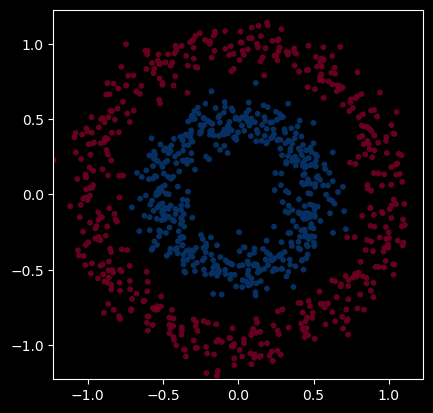

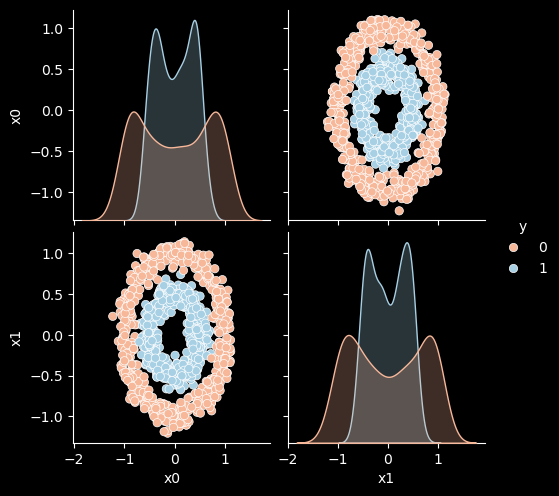

In [3]:
from sklearn.datasets import make_classification, make_blobs, make_moons, make_circles

n_samples = 1000

choice = 3

if   choice == 0:
    X, y = make_blobs(n_samples=n_samples, n_features=2, centers=2, cluster_std=4, random_state=10)
elif choice == 1:
    X, y = make_classification(n_samples=n_samples, n_features=2, n_informative=2,
                                n_redundant=0, n_clusters_per_class=1, n_classes=3, random_state=41)
elif choice == 2:
    X, y = make_moons(n_samples=n_samples, noise=0.2, random_state=42)
elif choice == 3:
    X, y = make_circles(n_samples=n_samples, noise=0.09, factor=0.5, random_state=42)

X = X - X.mean(axis=0)

MAX = np.max(np.abs(X))

n_classes = np.unique(y).shape[0]

plt.scatter(X[:,0], X[:,1], c=y, s=10, cmap='RdBu')
plt.xlim(-MAX, MAX); plt.ylim(-MAX, MAX)
plt.gca().set_aspect('equal')
plt.show()

df = pd.DataFrame({'x0': X[:,0], 'x1': X[:,1], 'y': y})
sns.pairplot(df, hue='y', palette='RdBu')
plt.show()

## Modeling

## Train/test split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

## Keras

In [5]:
from keras.models import Sequential
from keras.layers import *
from keras.optimizers import Adam

model = Sequential([
    Input(shape=X.shape[1:]),
    Dense(5),
    BatchNormalization(),
    Activation('relu'),
    Dense(5),
    BatchNormalization(),
    Activation('relu'),
    Dense(5),
    BatchNormalization(),
    Activation('relu'),
    Dense(n_classes, activation='softmax'),
])

optimizer = Adam(learning_rate=0.002)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5)              │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5)              │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5)              │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147 (588.00 B)

 Trainable params: 117 (468.00 B)

 Non-trainable params: 30 (120.00 B)

## Animate

We train one epoch at a time and capture the decision boundary grid at each step, then assemble the frames into an animated GIF.

In [6]:
nGrid = 200
a1 = np.linspace(-MAX, MAX, nGrid)
a2 = np.linspace(-MAX, MAX, nGrid)

A1, A2 = np.meshgrid(a1, a2)
A1 = A1.flatten()
A2 = A2.flatten()
A = np.vstack((A1, A2)).T

extent = [-MAX, MAX, -MAX, MAX]

100%|███████████| 150/150 [02:50<00:00,  1.14s/it]


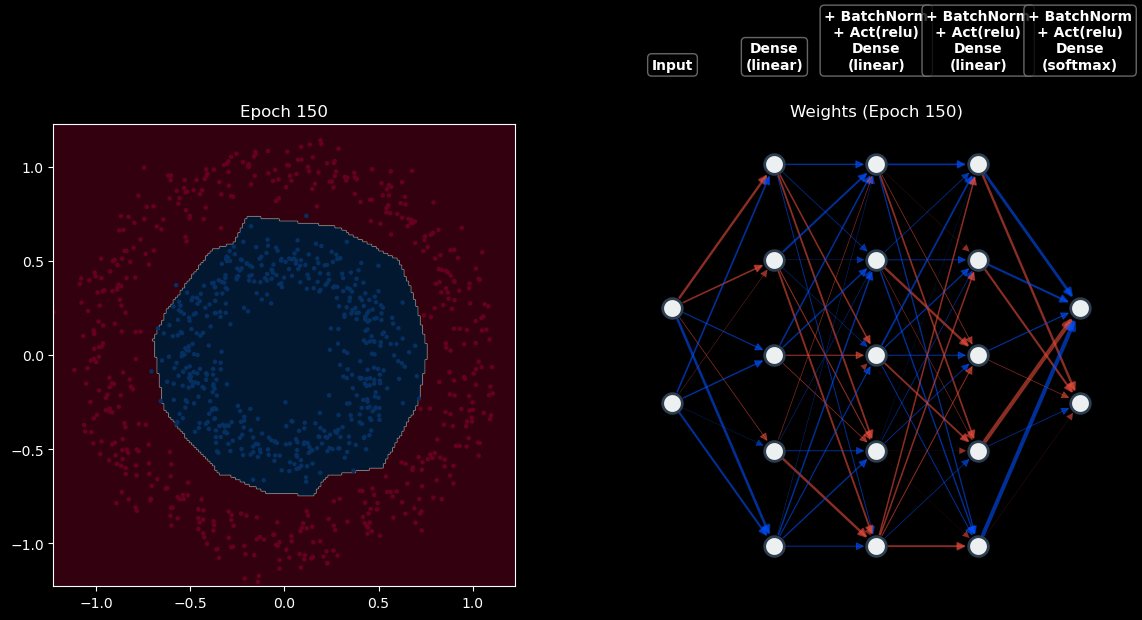

done


In [7]:
def animate(model, epochs, X_train, y_train, X_test, y_test, A, nGrid,
            filename='classification_training.gif'):
    cmap = 'RdBu'
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    predicted_frames = []
    weight_snapshots = []

    for i in tqdm(range(epochs), ncols=50):
        model.fit(X_train, y_train, epochs=1, batch_size=128,
                  validation_data=(X_test, y_test), verbose=0)
        B = model.predict(A, verbose=0).argmax(axis=1).reshape(nGrid, nGrid)
        predicted_frames.append(np.flipud(B))
        weight_snapshots.append(_get_model_graph_data(model))

    # Left subplot: decision boundary
    axes[0].scatter(X[:, 0], X[:, 1], c=y, s=5, cmap=cmap, zorder=2)
    region_plot = axes[0].imshow(predicted_frames[0], animated=True, cmap=cmap,
                                  alpha=0.5, extent=extent)
    axes[0].set_aspect('equal')
    axes[0].set_title('Epoch 1')

    # Right subplot: network weights (initial draw)
    _draw_network_on_ax(*weight_snapshots[0], axes[1])
    axes[1].set_title('Weights (Epoch 1)')

    def update(frame):
        region_plot.set_data(predicted_frames[frame])
        axes[0].set_title(f'Epoch {frame + 1}')
        axes[1].clear()
        _draw_network_on_ax(*weight_snapshots[frame], axes[1])
        axes[1].set_title(f'Weights (Epoch {frame + 1})')
        return region_plot,

    ani = animation.FuncAnimation(fig, update, frames=len(predicted_frames),
                                  interval=50, blit=False)
    ani.save(filename, writer='pillow', fps=5)
    plt.show()
    return ani


epochs = 150

animate(model, epochs, X_train, y_train, X_test, y_test, A, nGrid,
        filename='classification_training.gif')

print('done')